In [1]:
# Phase 13 – RL Evaluation | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sys
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase13"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11"
P12 = PROJECT / "outputs" / "phase12"

print("=" * 60)
print("Phase 13 – RL Evaluation | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

for p in [str(P8), str(P10), str(P11 / "data")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

# Stage I PPO
ppo_path = P9 / "models" / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "models" / "PPO_moderate.zip"
stage1_ppo = PPO.load(str(ppo_path))
print("Stage I PPO:", ppo_path.name)

# TD3 stage II
td3_models = {}
for series in ["standard", "strong"]:
    path = P11 / "models" / f"TD3_{series}_r.zip"
    if not path.exists():
        path = P11 / "models" / f"TD3_{series}.zip"
    td3_models[series] = TD3.load(str(path))
    print(f"TD3 [{series}]: {path.name}")

# MAPPO RLlib
import ray
from ray.tune.registry import register_env
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
from ray.rllib.algorithms.algorithm import Algorithm

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, include_dashboard=False, logging_level="ERROR")

# ensure apply_shock exists
if not hasattr(ShockEconomicsEnv, "apply_shock"):
    def _apply_shock(self, shock_type, severity="Moderate", series=None):
        if series is None:
            series = getattr(self, "shock_series", "standard") or "standard"
        sev_mult = {"Mild": 0.25, "Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}.get(str(severity), 0.5)
        series_mult = 1.0 if str(series) == "standard" else 1.6
        base_impact = {"Recession": 0.25, "Inflation": 0.15, "BankingCrisis": 0.30, "DebtCrisis": 0.22}.get(str(shock_type), 0.20)
        delta = -float(base_impact) * float(sev_mult) * float(series_mult)
        self.current_sr = np.clip(np.asarray(self.current_sr, dtype=np.float32) + delta, -1.0, 10.0)
        if getattr(self, "current_features", None) is not None:
            self.current_features = np.asarray(self.current_features, dtype=np.float32) + 0.5 * delta
        self.last_shock_info = {"shock_type": shock_type, "severity": severity, "series": series, "delta_sr": delta}
        return self.last_shock_info
    ShockEconomicsEnv.apply_shock = _apply_shock
    print("Patched apply_shock")

# register dummy envs for checkpoint restore
try:
    from economics_ma_pettingzoo import EconomicsMAParallelEnv
    def _reg(series):
        def creator(config):
            e = EconomicsMAParallelEnv(
                base_features, emb, sr_vector, panel, nodes,
                level="moderate", shock_type="BankingCrisis", severity="Moderate",
                shock_series=series, seed=0,
            )
            return ParallelPettingZooEnv(e)
        register_env(f"econ_ma_{series}_mappo", creator)
    for s in ["standard", "strong"]:
        _reg(s)
except Exception as e:
    print("PettingZoo register warning:", e)

mappo_algos = {}
for series in ["standard", "strong"]:
    path = P11 / "models" / f"MAPPO_{series}_rllib"
    if not path.exists():
        print("Missing MAPPO", series)
        continue
    loaded = False
    for c in [path] + [p for p in path.rglob("*") if p.is_dir()]:
        try:
            mappo_algos[series] = Algorithm.from_checkpoint(str(c))
            print(f"MAPPO [{series}] restored")
            loaded = True
            break
        except Exception:
            continue
    if not loaded:
        print("FAILED MAPPO", series)

print("MAPPO loaded:", list(mappo_algos.keys()))
print(f"base_features {base_features.shape} | emb {emb.shape}")
print("Cell 1 completed successfully.")

Phase 13 – RL Evaluation | Cell 1
Timestamp : 2026-10-04 09:45:15
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase13
Stage I PPO: PPO_moderate_gs.zip
TD3 [standard]: TD3_standard_r.zip
TD3 [strong]: TD3_strong_r.zip


2026-10-04 09:45:32,100	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-10-04 09:45:33,167	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Patched apply_shock
MAPPO [standard] restored
MAPPO [strong] restored
MAPPO loaded: ['standard', 'strong']
base_features (378, 16) | emb (378, 32)
Cell 1 completed successfully.


In [2]:
# Phase 13 – Cell 2: Full multi-metric evaluation (no shortcuts)

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase13" / "tables"
OUT_DATA = PROJECT / "outputs" / "phase13" / "data"

print("=" * 60)
print("Phase 13 – Cell 2: Full evaluation")
print("=" * 60)

STAGE1_STEPS = 10
STAGE2_STEPS = 30
N_EP = 20
SEEDS = [0, 1, 2]
SERIES_LIST = ["standard", "strong"]
SCENARIOS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("Recession", "Severe"),
    ("DebtCrisis", "Moderate"),
    ("Inflation", "Severe"),
]

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def joint6_to_base4(joint6, adim):
    tax, sub, rate, qe, credit, risk = joint6[:6]
    base = np.array([
        tax,
        0.5 * sub + 0.3 * qe,
        0.4 * qe + 0.3 * risk,
        0.5 * credit + 0.2 * rate,
    ], dtype=np.float32)
    if base.size < adim:
        base = np.pad(base, (0, adim - base.size))
    return np.clip(base[:adim], -1.0, 1.0)

def act_stage1(obs, env):
    a, _ = stage1_ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return a[:adim]

def act_td3(obs, series, env):
    a, _ = td3_models[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        return joint6_to_base4(a, adim)
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def act_mappo(obs, series, env):
    algo = mappo_algos[series]
    actions = []
    for i in range(3):
        o = np.asarray(obs, dtype=np.float32).copy()
        if o.size >= 3:
            o[-3:] = 0.0
            o[-3 + i] = 1.0
        try:
            act = algo.compute_single_action(o, policy_id="shared_policy")
        except Exception:
            act = algo.compute_single_action(o)
        if isinstance(act, tuple):
            act = act[0]
        a = np.asarray(act, dtype=np.float32).reshape(-1)
        if a.size < 2:
            a = np.pad(a, (0, 2 - a.size))
        actions.append(a[:2])
    joint = np.concatenate(actions)
    if joint.size < 6:
        joint = np.pad(joint, (0, 6 - joint.size))
    return joint6_to_base4(joint, env.action_space.shape[0])

def act_random(env):
    return env.action_space.sample()

def run_episode(arch, policy, series, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", shock_type=None, severity=None,
        shock_series=series, seed=seed,
    )
    obs, info = env.reset(seed=seed)
    ep_r = 0.0
    rewards_steps = []

    if arch == "hierarchical":
        for _ in range(STAGE1_STEPS):
            a = act_stage1(obs, env)
            obs, r, term, trunc, info = env.step(a)
            ep_r += float(r); rewards_steps.append(float(r))
            if term or trunc:
                break
        sr_s1 = get_sr(env)
        env.apply_shock(shock_type, severity, series)
        sr_shock = get_sr(env)
        obs = rebuild_obs(env)
        for _ in range(STAGE2_STEPS):
            if policy == "TD3":
                a = act_td3(obs, series, env)
            elif policy == "MAPPO":
                a = act_mappo(obs, series, env)
            else:
                a = act_random(env)
            obs, r, term, trunc, info = env.step(a)
            ep_r += float(r); rewards_steps.append(float(r))
            if term or trunc:
                break
    else:
        # flat / random: shock first, then one policy for full horizon
        env.apply_shock(shock_type, severity, series)
        sr_s1 = np.nan
        sr_shock = get_sr(env)
        obs = rebuild_obs(env)
        for _ in range(STAGE1_STEPS + STAGE2_STEPS):
            if policy == "TD3":
                a = act_td3(obs, series, env)
            elif policy == "MAPPO":
                a = act_mappo(obs, series, env)
            else:
                a = act_random(env)
            obs, r, term, trunc, info = env.step(a)
            ep_r += float(r); rewards_steps.append(float(r))
            if term or trunc:
                break

    sr_end = get_sr(env)
    return {
        "reward": ep_r,
        "median_step_reward": float(np.median(rewards_steps)) if rewards_steps else np.nan,
        "sr_after_stage1": sr_s1,
        "sr_after_shock": sr_shock,
        "sr_end": sr_end,
        "recovery": sr_end - sr_shock,
        "final_gap_vs_stage1": (sr_end - sr_s1) if sr_s1 == sr_s1 else np.nan,
    }

CONFIGS = [
    ("hierarchical", "TD3"),
    ("hierarchical", "MAPPO"),
    ("flat", "TD3"),
    ("flat", "MAPPO"),
    ("flat", "RANDOM"),
]

raw_rows = []
for series in SERIES_LIST:
    for shock_type, severity in SCENARIOS:
        for arch, pol in CONFIGS:
            ep_records = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    s = seed * 10_000 + ep
                    st = run_episode(arch, pol, series, shock_type, severity, s)
                    st.update({
                        "series": series,
                        "shock_type": shock_type,
                        "severity": severity,
                        "architecture": arch,
                        "policy": pol,
                        "seed": seed,
                        "episode": ep,
                    })
                    ep_records.append(st)
                    raw_rows.append(st)
            # progress
            rs = [x["reward"] for x in ep_records]
            print(f"{series:8s} | {shock_type:14s}/{severity:8s} | {arch:13s}/{pol:6s} | "
                  f"R={np.mean(rs):7.3f}±{np.std(rs):5.3f}")

raw = pd.DataFrame(raw_rows)
raw.to_csv(OUT_TAB / "phase13_eval_raw.csv", index=False)
print("\nRaw rows:", len(raw))
print("Saved:", OUT_TAB / "phase13_eval_raw.csv")
print("Cell 2 completed successfully.")

Phase 13 – Cell 2: Full evaluation
standard | BankingCrisis /Moderate | hierarchical /TD3    | R= 28.128±0.526
standard | BankingCrisis /Moderate | hierarchical /MAPPO  | R= 19.132±1.183
standard | BankingCrisis /Moderate | flat         /TD3    | R= 23.039±0.457
standard | BankingCrisis /Moderate | flat         /MAPPO  | R=  6.048±1.438
standard | BankingCrisis /Moderate | flat         /RANDOM | R=-11.463±1.844
standard | BankingCrisis /Severe   | hierarchical /TD3    | R= 25.942±0.553
standard | BankingCrisis /Severe   | hierarchical /MAPPO  | R= 16.681±1.157
standard | BankingCrisis /Severe   | flat         /TD3    | R= 19.905±0.468
standard | BankingCrisis /Severe   | flat         /MAPPO  | R=  2.425±1.358
standard | BankingCrisis /Severe   | flat         /RANDOM | R=-14.334±1.705
standard | Recession     /Moderate | hierarchical /TD3    | R= 28.819±0.517
standard | Recession     /Moderate | hierarchical /MAPPO  | R= 20.112±0.937
standard | Recession     /Moderate | flat         /TD

Phase 13 – Cell 3: Metrics & ranking

=== FULL RANKING (by composite) ===
  series architecture policy  mean_reward  median_reward  mean_sr_end  mean_recovery  stability_reward  stability_sr  composite
standard hierarchical    TD3    28.054074      28.081560     1.497916       0.832223          0.432198      0.999269   5.242847
standard         flat    TD3    22.970969      23.038764     1.493930       1.307295          0.340111      0.996398   3.457658
standard hierarchical  MAPPO    19.131208      19.149450     1.210944       0.545251          0.388221      0.963982   0.139758
standard         flat  MAPPO     5.751897       5.789572     0.947317       0.760682          0.323708      0.958622  -2.821000
standard         flat RANDOM   -11.656665     -11.760655     0.213279       0.026643          0.357257      0.966407  -6.019263
  strong         flat    TD3    19.675537      19.744822     1.485253       1.389618          0.305025      0.991316   3.815525
  strong hierarchical    TD3  

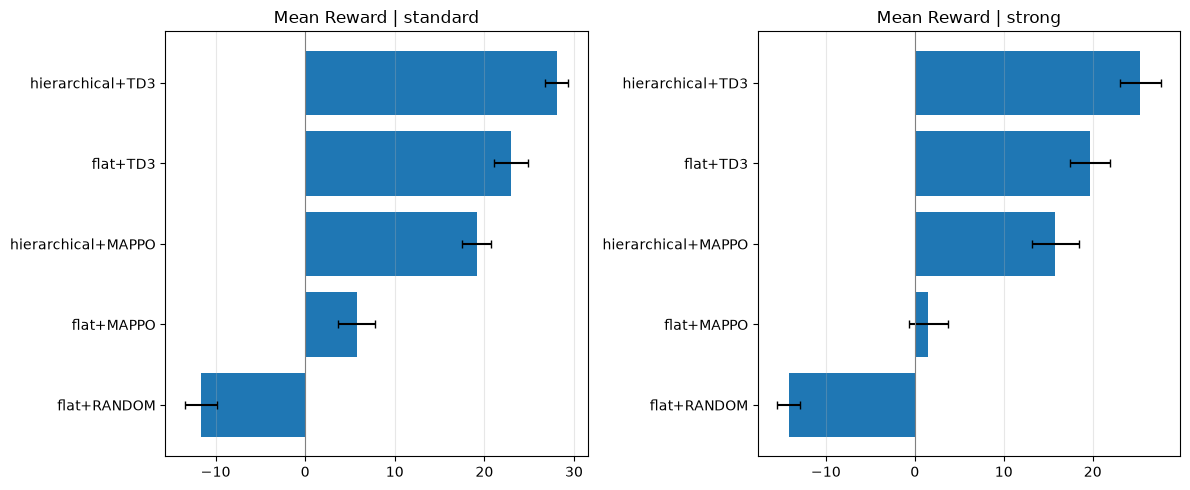

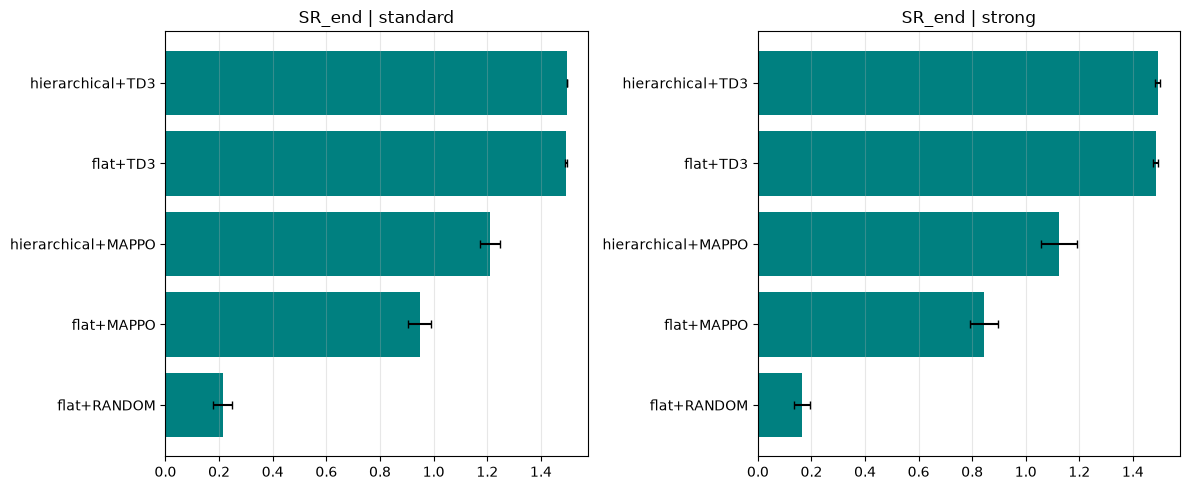

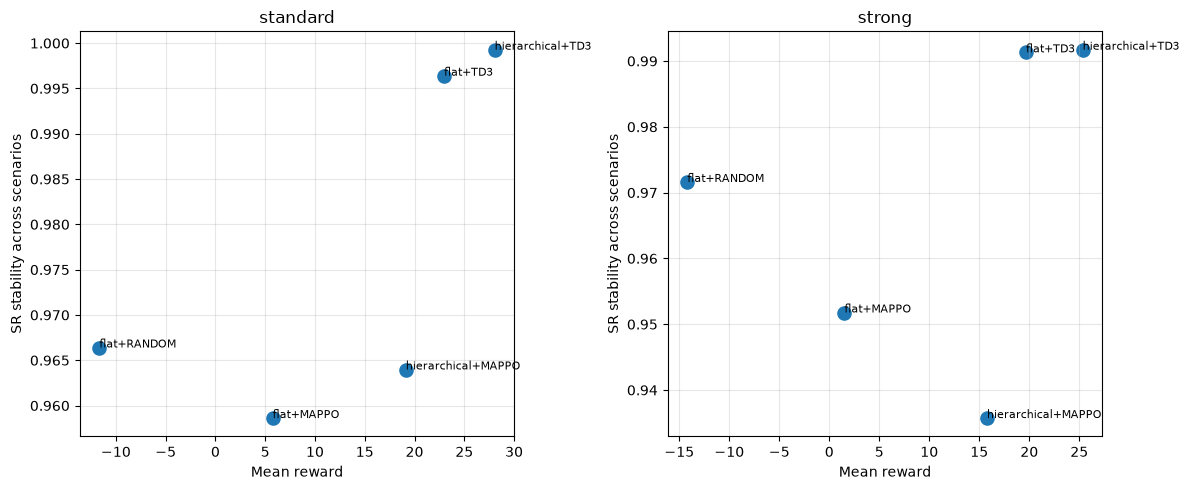


Saved rankings + figures.
Cell 3 completed successfully.
PHASE 13 EVALUATION COMPLETED.


In [3]:
# Phase 13 – Cell 3: Metrics, rankings, figures

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase13" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase13" / "figures"

print("=" * 60)
print("Phase 13 – Cell 3: Metrics & ranking")
print("=" * 60)

raw = pd.read_csv(OUT_TAB / "phase13_eval_raw.csv")

# per config × series × scenario
grp = (
    raw.groupby(["series", "architecture", "policy", "shock_type", "severity"], as_index=False)
       .agg(
           mean_reward=("reward", "mean"),
           median_reward=("reward", "median"),
           std_reward=("reward", "std"),
           var_reward=("reward", "var"),
           mean_sr_end=("sr_end", "mean"),
           std_sr_end=("sr_end", "std"),
           mean_recovery=("recovery", "mean"),
           std_recovery=("recovery", "std"),
           n=("reward", "count"),
       )
)
grp.to_csv(OUT_TAB / "phase13_by_scenario.csv", index=False)

# aggregate over scenarios
agg = (
    grp.groupby(["series", "architecture", "policy"], as_index=False)
       .agg(
           mean_reward=("mean_reward", "mean"),
           median_reward=("median_reward", "mean"),
           std_reward_within=("std_reward", "mean"),
           std_reward_across_scenarios=("mean_reward", "std"),
           mean_sr_end=("mean_sr_end", "mean"),
           std_sr_end_across_scenarios=("mean_sr_end", "std"),
           mean_recovery=("mean_recovery", "mean"),
           std_recovery_across_scenarios=("mean_recovery", "std"),
       )
)
agg["stability_reward"] = 1.0 / (1.0 + agg["std_reward_across_scenarios"].fillna(0))
agg["stability_sr"] = 1.0 / (1.0 + agg["std_sr_end_across_scenarios"].fillna(0))
# composite z-scores within series
rows = []
for series, g in agg.groupby("series"):
    g = g.copy()
    for col in ["mean_reward", "mean_sr_end", "mean_recovery", "stability_reward", "stability_sr"]:
        mu, sd = g[col].mean(), g[col].std(ddof=0)
        g[f"z_{col}"] = (g[col] - mu) / (sd if sd > 1e-8 else 1.0)
    g["composite"] = (
        g["z_mean_reward"] + g["z_mean_sr_end"] + g["z_mean_recovery"]
        + g["z_stability_reward"] + g["z_stability_sr"]
    )
    rows.append(g)
agg = pd.concat(rows, ignore_index=True)
agg = agg.sort_values(["series", "composite"], ascending=[True, False])
agg.to_csv(OUT_TAB / "phase13_summary_ranking.csv", index=False)

print("\n=== FULL RANKING (by composite) ===")
cols = ["series", "architecture", "policy", "mean_reward", "median_reward",
        "mean_sr_end", "mean_recovery", "stability_reward", "stability_sr", "composite"]
print(agg[cols].to_string(index=False))

# vs Random gaps
cmp_rows = []
for series in ["standard", "strong"]:
    sub = agg[agg.series == series]
    rnd = sub[(sub.architecture == "flat") & (sub.policy == "RANDOM")]
    if len(rnd) == 0:
        continue
    r_base = float(rnd.mean_reward.iloc[0])
    s_base = float(rnd.mean_sr_end.iloc[0])
    for _, row in sub.iterrows():
        if row["policy"] == "RANDOM":
            continue
        cmp_rows.append({
            "series": series,
            "architecture": row["architecture"],
            "policy": row["policy"],
            "reward_gap_vs_random": float(row["mean_reward"] - r_base),
            "sr_gap_vs_random": float(row["mean_sr_end"] - s_base),
            "composite": float(row["composite"]),
        })
cmp = pd.DataFrame(cmp_rows).sort_values(["series", "composite"], ascending=[True, False])
cmp.to_csv(OUT_TAB / "phase13_vs_random.csv", index=False)
print("\n=== Gap vs Random ===")
print(cmp.to_string(index=False))

# figures
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = agg[agg.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["policy"]
    sub = sub.sort_values("mean_reward")
    ax.barh(sub["label"], sub["mean_reward"], xerr=sub["std_reward_across_scenarios"], capsize=3)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"Mean Reward | {series}")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase13_mean_reward.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = agg[agg.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["policy"]
    sub = sub.sort_values("mean_sr_end")
    ax.barh(sub["label"], sub["mean_sr_end"], xerr=sub["std_sr_end_across_scenarios"], capsize=3, color="teal")
    ax.set_title(f"SR_end | {series}")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase13_sr_end.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = agg[agg.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["policy"]
    ax.scatter(sub["mean_reward"], sub["stability_sr"], s=90)
    for _, r in sub.iterrows():
        ax.annotate(r["label"], (r["mean_reward"], r["stability_sr"]), fontsize=8)
    ax.set_xlabel("Mean reward")
    ax.set_ylabel("SR stability across scenarios")
    ax.set_title(series)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase13_reward_vs_stability.png", dpi=150)
plt.show()

print("\nSaved rankings + figures.")
print("Cell 3 completed successfully.")
print("PHASE 13 EVALUATION COMPLETED.")

In [4]:
# Phase 13 – Cell 4: Retrain PPO & TD3 with learning logs

from pathlib import Path
import numpy as np
import pandas as pd
from stable_baselines3 import PPO, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise
from shock_env import ShockEconomicsEnv
from economics_env import EconomicsNetworkEnv

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase13" / "tables"
OUT_MODEL = PROJECT / "outputs" / "phase13" / "models"
OUT_MODEL.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 13 – Cell 4: PPO + TD3 retrain with logs")
print("=" * 60)

TOTAL_TIMESTEPS = 30000
EVAL_EVERY = 2000
SEED = 0

class LearnLogCallback(BaseCallback):
    def __init__(self, eval_env_fn, name, eval_every=EVAL_EVERY, verbose=0):
        super().__init__(verbose)
        self.eval_env_fn = eval_env_fn
        self.name = name
        self.eval_every = eval_every
        self.rows = []
        self._last = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last >= self.eval_every or self.num_timesteps >= TOTAL_TIMESTEPS:
            self._last = self.num_timesteps
            env = self.eval_env_fn()
            rewards = []
            for ep in range(5):
                obs, _ = env.reset(seed=1000 + ep)
                ep_r, done = 0.0, False
                while not done:
                    a, _ = self.model.predict(obs, deterministic=True)
                    obs, r, term, trunc, _ = env.step(a)
                    ep_r += float(r)
                    done = term or trunc
                rewards.append(ep_r)
            self.rows.append({
                "model": self.name,
                "timesteps": int(self.num_timesteps),
                "mean_reward": float(np.mean(rewards)),
                "std_reward": float(np.std(rewards)),
                "median_reward": float(np.median(rewards)),
            })
            print(f"  [{self.name}] steps={self.num_timesteps:6d} | evalR={np.mean(rewards):.3f}±{np.std(rewards):.3f}")
        return True

def make_stage1_env(seed=0):
    return EconomicsNetworkEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", seed=seed,
    )

def make_shock_env(series="standard", seed=0):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type="BankingCrisis", severity="Moderate",
        shock_series=series, seed=seed,
    )
    return env

all_logs = []

# ----- PPO Stage I -----
print("\n=== Train PPO Stage I ===")
train_env = DummyVecEnv([lambda: make_stage1_env(SEED)])
cb = LearnLogCallback(lambda: make_stage1_env(999), "PPO_StageI", EVAL_EVERY)
ppo = PPO("MlpPolicy", train_env, verbose=0, seed=SEED, learning_rate=3e-4, gamma=0.99)
ppo.learn(TOTAL_TIMESTEPS, callback=cb)
ppo.save(str(OUT_MODEL / "PPO_StageI_phase13.zip"))
pd.DataFrame(cb.rows).to_csv(OUT_TAB / "learnlog_PPO_StageI.csv", index=False)
all_logs.extend(cb.rows)
print("Saved PPO_StageI")

# ----- TD3 Stage II / Flat (standard + strong) -----
for series in ["standard", "strong"]:
    print(f"\n=== Train TD3 [{series}] ===")
    train_env = DummyVecEnv([lambda s=series: make_shock_env(s, SEED)])
    n_act = train_env.action_space.shape[0]
    noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))
    cb = LearnLogCallback(lambda s=series: make_shock_env(s, 999), f"TD3_{series}", EVAL_EVERY)
    model = TD3("MlpPolicy", train_env, verbose=0, seed=SEED, learning_rate=3e-4, gamma=0.99, action_noise=noise)
    model.learn(TOTAL_TIMESTEPS, callback=cb)
    model.save(str(OUT_MODEL / f"TD3_{series}_phase13.zip"))
    pd.DataFrame(cb.rows).to_csv(OUT_TAB / f"learnlog_TD3_{series}.csv", index=False)
    all_logs.extend(cb.rows)
    print(f"Saved TD3_{series}")

pd.DataFrame(all_logs).to_csv(OUT_TAB / "learnlog_ppo_td3_all.csv", index=False)
print("\nCell 4 completed successfully.")

Phase 13 – Cell 4: PPO + TD3 retrain with logs

=== Train PPO Stage I ===
  [PPO_StageI] steps=  2000 | evalR=-3.627±0.900
  [PPO_StageI] steps=  4000 | evalR=0.126±1.061
  [PPO_StageI] steps=  6000 | evalR=4.011±1.146
  [PPO_StageI] steps=  8000 | evalR=7.537±1.040
  [PPO_StageI] steps= 10000 | evalR=11.340±1.424
  [PPO_StageI] steps= 12000 | evalR=14.686±1.274
  [PPO_StageI] steps= 14000 | evalR=18.428±1.219
  [PPO_StageI] steps= 16000 | evalR=21.978±1.365
  [PPO_StageI] steps= 18000 | evalR=24.634±1.365
  [PPO_StageI] steps= 20000 | evalR=26.808±1.617
  [PPO_StageI] steps= 22000 | evalR=28.411±1.516
  [PPO_StageI] steps= 24000 | evalR=29.399±1.400
  [PPO_StageI] steps= 26000 | evalR=30.524±1.511
  [PPO_StageI] steps= 28000 | evalR=31.362±1.320
  [PPO_StageI] steps= 30000 | evalR=31.764±1.190
  [PPO_StageI] steps= 30001 | evalR=31.764±1.190
  [PPO_StageI] steps= 30002 | evalR=31.764±1.190
  [PPO_StageI] steps= 30003 | evalR=31.764±1.190
  [PPO_StageI] steps= 30004 | evalR=31.764±1.19

In [5]:
# Phase 13 – Cell 5: Retrain MAPPO with learning logs

from pathlib import Path
import numpy as np
import pandas as pd
import ray
from ray.tune.registry import register_env
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
from ray.rllib.algorithms.ppo import PPOConfig

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase13" / "tables"
OUT_MODEL = PROJECT / "outputs" / "phase13" / "models"

print("=" * 60)
print("Phase 13 – Cell 5: MAPPO retrain with logs")
print("=" * 60)

from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, include_dashboard=False, logging_level="ERROR")

TOTAL_TIMESTEPS = 30000
SEED = 0

def make_raw(series, seed=0):
    return EconomicsMAParallelEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type="BankingCrisis", severity="Moderate",
        shock_series=series, seed=seed,
    )

rows = []
for series in ["standard", "strong"]:
    env_name = f"econ_ma_{series}_mappo_p13"
    register_env(env_name, lambda cfg, s=series: ParallelPettingZooEnv(make_raw(s, SEED)))

    probe = ParallelPettingZooEnv(make_raw(series, 0))
    obs_space, act_space = probe.observation_space, probe.action_space
    sample_obs = list(obs_space.spaces.values())[0]
    sample_act = list(act_space.spaces.values())[0]
    agent_ids = list(obs_space.spaces.keys())
    probe.close()

    policies = {"shared_policy": (None, sample_obs, sample_act, {})}
    mapping = lambda agent_id, *args, **kwargs: "shared_policy"

    cfg = (
        PPOConfig()
        .environment(env=env_name, disable_env_checking=True)
        .framework("torch")
        .env_runners(num_env_runners=0, num_envs_per_env_runner=1, rollout_fragment_length=40)
        .training(lr=3e-4, gamma=0.99, train_batch_size=2048, minibatch_size=256, num_epochs=10,
                  model={"fcnet_hiddens": [128, 128]})
        .multi_agent(policies=policies, policy_mapping_fn=mapping, policies_to_train=["shared_policy"])
        .debugging(log_level="ERROR")
        .api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)
    )
    algo = cfg.build()
    print(f"\n=== MAPPO [{series}] ===")
    steps, it = 0, 0
    while steps < TOTAL_TIMESTEPS:
        result = algo.train()
        ts = (
            result.get("num_env_steps_sampled_lifetime")
            or result.get("env_runners", {}).get("num_env_steps_sampled_lifetime")
            or result.get("timesteps_total")
            or 0
        )
        steps = int(ts) if ts else steps + 2048
        rew = (
            result.get("env_runners", {}).get("episode_return_mean")
            or result.get("episode_reward_mean")
            or np.nan
        )
        it += 1
        if it % 3 == 0 or steps >= TOTAL_TIMESTEPS:
            rows.append({
                "model": f"MAPPO_{series}",
                "timesteps": steps,
                "mean_reward": float(rew) if rew is not None else np.nan,
                "std_reward": np.nan,
                "median_reward": np.nan,
                "iteration": it,
            })
            print(f"  iter={it:03d} | steps≈{steps:6d} | return={rew}")
        if it > 400:
            break
    ckpt = algo.save(str(OUT_MODEL / f"MAPPO_{series}_phase13"))
    print("Saved:", ckpt)
    algo.stop()

log_df = pd.DataFrame(rows)
log_df.to_csv(OUT_TAB / "learnlog_MAPPO.csv", index=False)
print("\nCell 5 completed successfully.")

Phase 13 – Cell 5: MAPPO retrain with logs

=== MAPPO [standard] ===
  iter=003 | steps≈  6240 | return=-32.226986635993065
  iter=006 | steps≈ 12480 | return=-17.946741151970222
  iter=009 | steps≈ 18720 | return=-2.4371141791219837
  iter=012 | steps≈ 24960 | return=1.472988475006398
  iter=015 | steps≈ 31200 | return=7.472261659761743
Saved: TrainingResult(checkpoint=Checkpoint(filesystem=local, path=D:\univercity\omid_project\economics_project\outputs\phase13\models\MAPPO_standard_phase13), metrics={'custom_metrics': {}, 'episode_media': {}, 'info': {'learner': {'shared_policy': {'learner_stats': {'allreduce_latency': 0.0, 'grad_gnorm': 14.596474661827088, 'cur_kl_coeff': 0.1, 'cur_lr': 0.0003, 'total_loss': 2.518629462718964, 'policy_loss': 0.0007192205190658569, 'vf_loss': 2.517079648017883, 'vf_explained_var': 0.5919650208950042, 'kl': 0.008305914545489965, 'entropy': 2.1524140272140504, 'entropy_coeff': 0.0}, 'model': {}, 'custom_metrics': {}, 'num_agent_steps_trained': 249.6, 

Phase 13 – Cell 6: Learning-curve metrics
Loaded learnlog_ppo_td3_all.csv 765
Loaded learnlog_MAPPO.csv 10

=== Learning metrics ===
 final_reward  best_reward  convergence_steps_90pct  sample_efficiency_auc_norm  training_stability_std_last  training_stability_mad  n_eval_points  max_timesteps          model
    31.763610    31.763610                  22000.0                   19.132797                 3.552714e-15                0.048216            735        30720.0     PPO_StageI
    28.785666    28.806985                   8000.0                   27.111024                 1.747746e-02                0.971666             15        30000.0   TD3_standard
    20.497481    20.497481                  12000.0                   20.146006                 2.770640e-03                0.146338             15        30000.0     TD3_strong
     7.472262     7.472262                  31200.0                   -7.822057                 4.075345e+00                9.924812              5        

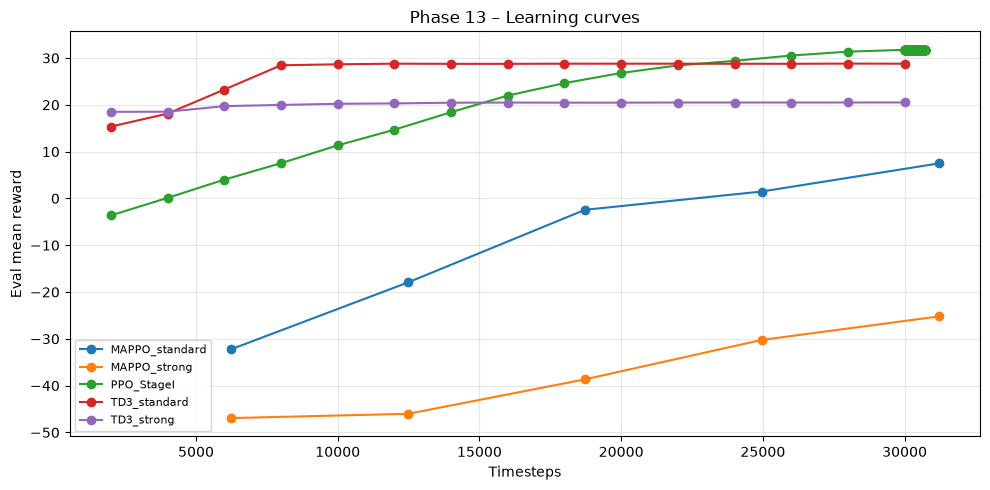


Cell 6 completed successfully.
PHASE 13 LEARNING METRICS COMPLETED.


In [6]:
# Phase 13 – Cell 6: Convergence, sample efficiency, training stability

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase13" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase13" / "figures"

print("=" * 60)
print("Phase 13 – Cell 6: Learning-curve metrics")
print("=" * 60)

parts = []
for name in ["learnlog_ppo_td3_all.csv", "learnlog_MAPPO.csv"]:
    p = OUT_TAB / name
    if p.exists():
        parts.append(pd.read_csv(p))
        print("Loaded", name, len(parts[-1]))
    else:
        print("Missing", name)

log = pd.concat(parts, ignore_index=True)
log = log.dropna(subset=["mean_reward"])
log.to_csv(OUT_TAB / "learnlog_all_models.csv", index=False)

def metrics_for_model(g):
    g = g.sort_values("timesteps")
    ts = g["timesteps"].values.astype(float)
    rw = g["mean_reward"].values.astype(float)
    if len(rw) < 2:
        return None
    final = float(rw[-1])
    best = float(np.max(rw))
    # convergence: first time reaching 90% of best improvement from start
    start = float(rw[0])
    target = start + 0.9 * (best - start) if best > start else best
    conv_idx = np.where(rw >= target)[0]
    conv_steps = float(ts[conv_idx[0]]) if len(conv_idx) else float(ts[-1])
    # sample efficiency: AUC of reward vs timesteps (normalized)
    auc = float(np.trapz(rw, ts))
    auc_norm = auc / (ts[-1] - ts[0] + 1e-8)
    # training stability: std of last 3 eval points + mean abs diff
    last = rw[-3:] if len(rw) >= 3 else rw
    stab_std = float(np.std(last))
    stab_mad = float(np.mean(np.abs(np.diff(rw)))) if len(rw) > 1 else 0.0
    return {
        "final_reward": final,
        "best_reward": best,
        "convergence_steps_90pct": conv_steps,
        "sample_efficiency_auc_norm": auc_norm,
        "training_stability_std_last": stab_std,
        "training_stability_mad": stab_mad,
        "n_eval_points": int(len(rw)),
        "max_timesteps": float(ts[-1]),
    }

rows = []
for model, g in log.groupby("model"):
    m = metrics_for_model(g)
    if m:
        m["model"] = model
        rows.append(m)

met = pd.DataFrame(rows)
# lower convergence_steps better; lower stability_std better; higher auc better
met = met.sort_values("best_reward", ascending=False)
met.to_csv(OUT_TAB / "phase13_learning_metrics.csv", index=False)
print("\n=== Learning metrics ===")
print(met.to_string(index=False))

# curves
fig, ax = plt.subplots(figsize=(10, 5))
for model, g in log.groupby("model"):
    g = g.sort_values("timesteps")
    ax.plot(g["timesteps"], g["mean_reward"], marker="o", label=model)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Eval mean reward")
ax.set_title("Phase 13 – Learning curves")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase13_learning_curves.png", dpi=150)
plt.show()

print("\nCell 6 completed successfully.")
print("PHASE 13 LEARNING METRICS COMPLETED.")